# Portafolio de visualizaciones interpretadas — Delitos en Colombia (2020-2026)

**Actividad 15 híbrida — Representación y métodos gráficos**

**Enfoque social:** este portafolio compara delitos a nivel nacional para identificar líneas de tiempo (2020-2026) y diferencias geográficas entre departamentos y municipios de Colombia, usando datos oficiales de la Policía Nacional filtrados a seis delitos de alto impacto social: violencia intrafamiliar, amenazas, delitos sexuales, homicidio intencional, extorsión y secuestro.

Para cada pregunta analítica se sigue la estructura de interpretación:

> **Hallazgo:** patrón visible en el gráfico.
> **Evidencia:** cifras o elementos del gráfico que lo sustentan.
> **Precaución:** limitación o algo que el gráfico no permite concluir.


In [6]:
import sys
from pathlib import Path

RAIZ_PROYECTO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(RAIZ_PROYECTO) not in sys.path:
    sys.path.append(str(RAIZ_PROYECTO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.ingesta import cargar_consolidado
from src.graficos import aplicar_estilo

aplicar_estilo()
pd.options.display.float_format = "{:,.2f}".format

df = cargar_consolidado()
df.shape

(1605036, 15)

## Diccionario de datos

El conjunto de datos contiene información oficial de la Policía Nacional sobre **1.605.035 casos de delitos de alto impacto social** registrados en Colombia entre 2020 y 2026 (2026 es parcial, con datos hasta agosto). Cada fila representa un caso individual y las columnas describen el tipo de delito, el lugar y momento del hecho, y características de la persona asociada al caso.

| Columna | Tipo de variable | Descripción |
|---|---|---|
| `DEPARTAMENTO` | Categórica nominal | Departamento donde ocurrió el hecho (33 valores, nombres normalizados). |
| `MUNICIPIO` | Categórica nominal | Municipio donde ocurrió el hecho (1.104 valores). |
| `FECHA_HECHO` | Temporal | Fecha en que ocurrió el hecho. |
| `AÑO` | Categórica ordinal / Temporal | Año derivado de `FECHA_HECHO`. Incluye valores entre 2020 y 2026. |
| `MES` | Categórica ordinal / Temporal | Mes del hecho, de 1 a 12. |
| `GENERO` | Categórica nominal | Género de la persona asociada al caso. |
| `GRUPO_EDAD` | Categórica ordinal | Grupo etario de la persona asociada al caso. |
| `ARMAS_MEDIOS` | Categórica nominal | Arma o medio empleado en el hecho. |
| `TIPO_DELITO` | Categórica nominal | Delito registrado: violencia intrafamiliar, amenaza, delitos sexuales, homicidio intencional, extorsión o secuestro. |
| `CODIGO_DELITO` / `ICCS` | Identificador | Código de clasificación del delito (ICCS: Clasificación Internacional de Delitos con Fines Estadísticos). |
| `CODIGO_DANE` | Identificador | Código DANE del municipio, útil para geo-referenciación. |
| `CANTIDAD` | Numérica discreta | Número de casos que representa la fila (normalmente 1). |
| `ARCHIVO_ORIGEN` | Identificador | Archivo Excel del que proviene la fila (trazabilidad). |

### Interpretación general

Cada fila del conjunto de datos puede entenderse como la respuesta a la pregunta:

> **¿Qué caso de un delito de alto impacto social ocurrió, dónde y cuándo?**

Las columnas permiten analizar aspectos como:

- el tipo de delito,
- el departamento y municipio donde ocurrió,
- el género y grupo etario de la persona asociada,
- el arma o medio empleado,
- y el momento (año y mes) en que se registró el caso.

**Nota de calidad de datos:** durante la construcción del pipeline se corrigieron dos inconsistencias entre archivos de distintos años: nombres de departamento distintos para el mismo lugar (p. ej. "Valle" vs. "Valle del Cauca del Cauca") y Bogotá D.C. etiquetada como "Cundinamarca" en 2020-2024 y como "Bogotá" en 2025-2026 (se unificó por código DANE).


In [7]:
# Observamos las primeras filas.
df.head(-1)

,ARMAS_MEDIOS,DEPARTAMENTO,MUNICIPIO,FECHA_HECHO,GENERO,GRUPO_EDAD,CODIGO_DANE,DELITO_RAW,MES,CANTIDAD,ICCS,CODIGO_DELITO,TIPO_DELITO,ARCHIVO_ORIGEN,AÑO
0,ARMA BLANCA / CORTOPUNZANTE,CUNDINAMARCA,Chocontá,2020-01-10,FEMENINO,DE 18 AÑOS Y MÁS,"25,183.00",(02089) Otros actos dirigidos a inducir miedo ...,1.00,1.00,"2,089.00",2089,Otros actos dirigidos a inducir miedo o angust...,INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO...,2020
1,ARMA BLANCA / CORTOPUNZANTE,CUNDINAMARCA,Villapinzón,2020-02-20,FEMENINO,DE 18 AÑOS Y MÁS,"25,873.00",(02089) Otros actos dirigidos a inducir miedo ...,2.00,1.00,"2,089.00",2089,Otros actos dirigidos a inducir miedo o angust...,INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO...,2020
2,SIN EMPLEO DE ARMAS,BOGOTA,Bogotá D.C.,2020-01-01,FEMENINO,DE 18 AÑOS Y MÁS,"11,001.00",(02089) Otros actos dirigidos a inducir miedo ...,1.00,1.00,"2,089.00",2089,Otros actos dirigidos a inducir miedo o angust...,INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO...,2020
3,CONTUNDENTES,TOLIMA,Ibagué,2020-01-01,FEMENINO,DE 18 AÑOS Y MÁS,"73,001.00",(02089) Otros actos dirigidos a inducir miedo ...,1.00,1.00,"2,089.00",2089,Otros actos dirigidos a inducir miedo o angust...,INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO...,2020
4,CONTUNDENTES,BOGOTA,Bogotá D.C.,2020-01-01,FEMENINO,DE 18 AÑOS Y MÁS,"11,001.00",(02089) Otros actos dirigidos a inducir miedo ...,1.00,1.00,"2,089.00",2089,Otros actos dirigidos a inducir miedo o angust...,INFORMACIÓN_DE_DELITOS_A_NIVEL_DE_REGISTRO_AÑO...,2020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1605030,SIN EMPLEO DE ARMAS,ANTIOQUIA,Sabanalarga,2026-07-16,FEMENINO,DE 18 AÑOS Y MÁS,"5,628.00",(02012) Amenaza,7.00,1.00,"2,012.00",2012,Amenaza,INFORMACIÓN_DELITOS_A_NIVEL_DE_REGISTRO_AÑO_20...,2026
1605031,SIN EMPLEO DE ARMAS,BOGOTA,Bogotá D.C.,2026-08-14,FEMENINO,DE 18 AÑOS Y MÁS,"11,001.00",(02012) Amenaza,8.00,1.00,"2,012.00",2012,Amenaza,INFORMACIÓN_DELITOS_A_NIVEL_DE_REGISTRO_AÑO_20...,2026
1605032,SIN EMPLEO DE ARMAS,HUILA,Rivera,2026-06-16,MASCULINO,DE 18 AÑOS Y MÁS,"41,615.00",(02012) Amenaza,6.00,1.00,"2,012.00",2012,Amenaza,INFORMACIÓN_DELITOS_A_NIVEL_DE_REGISTRO_AÑO_20...,2026
1605033,SIN EMPLEO DE ARMAS,CALDAS,Manizales,2026-08-01,FEMENINO,DE 18 AÑOS Y MÁS,"17,001.00",(02012) Amenaza,8.00,1.00,"2,012.00",2012,Amenaza,INFORMACIÓN_DELITOS_A_NIVEL_DE_REGISTRO_AÑO_20...,2026


## Pregunta 1 (Comparativa): ¿Cómo ha sido la evolución y el comportamiento estadístico de los delitos de alto impacto social: violencia intrafamiliar, amenazas, delitos sexuales, homicidio intencional, extorsión y secuestro, por departamento a lo largo de los años (2020-2026)?

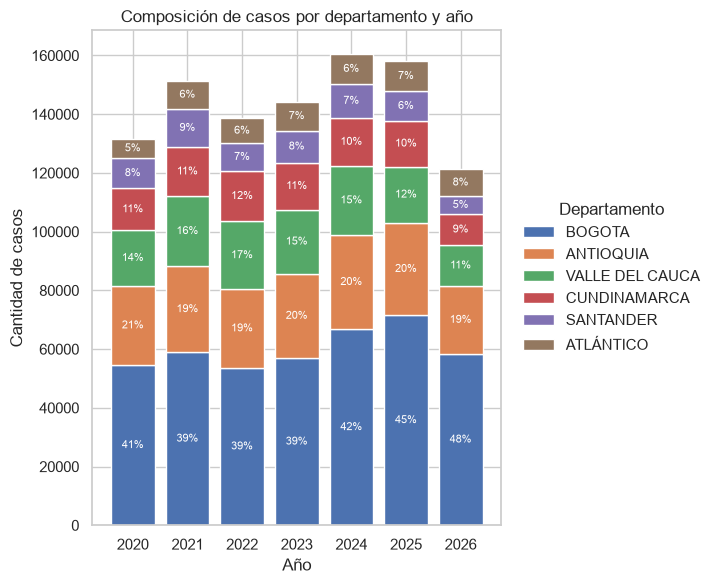

In [8]:
df['AÑO'] = df['FECHA_HECHO'].dt.year

top_departamentos = (
    df.groupby("DEPARTAMENTO")["CANTIDAD"].sum().sort_values(ascending=False).head(6).index.tolist()
)

anual_depto = (
    df[df["DEPARTAMENTO"].isin(top_departamentos)]
      .groupby(["AÑO", "DEPARTAMENTO"])["CANTIDAD"]
      .sum()
      .unstack("DEPARTAMENTO")
      .reindex(columns=top_departamentos)
)

porcentajes = anual_depto.div(anual_depto.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(9, 6))
base = pd.Series(0, index=anual_depto.index, dtype=float)
for depto in top_departamentos:
    valores = anual_depto[depto]
    barras = ax.bar(anual_depto.index.astype(str), valores, bottom=base, label=depto)
    for barra, valor, pct in zip(barras, valores, porcentajes[depto]):
        if pct >= 4:  # se omite la etiqueta en segmentos muy angostos para no saturar
            ax.text(
                barra.get_x() + barra.get_width() / 2,
                barra.get_y() + barra.get_height() / 2,
                f"{pct:.0f}%",
                ha="center", va="center", fontsize=8, color="white",
            )
    base += valores

ax.set_title("Composición de casos por departamento y año")
ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de casos")
ax.legend(
    title="Departamento",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)
plt.xticks(rotation=0)
fig.tight_layout(rect=(0, 0, 0.82, 1))  # reserva ~18% del ancho a la derecha para la leyenda
plt.show()



**Hallazgo:** la participación de Bogotá dentro del total de los 6 departamentos con los delitos de alto impacto social: violencia intrafamiliar, amenazas, delitos sexuales, homicidio intencional, extorsión y secuestro. ha aumentado de forma sostenida en los últimos años, mientras que la de Valle del Cauca y Santander ha ido disminuyendo, teniendo en cuenta que para el año 2026 solo contemplamos el primer semestre.

**Evidencia:** Bogotá pasó de representar cerca del 39% del total en 2021-2023 a 48% en 2026; en el mismo periodo, Valle del Cauca cayó de 17% (2022) a 11% (2026), y Santander de 9% (2021) a 5% (2026).

**Precaución:** Dentro de la gráfica no podemos concluir:
- Cuales son los tipos de delitos que más se cometen.
- Si dentro del porcentaje de cada departamento predominan los delitos de tipo orden público y seguridad del Estado (Extorsión y secuestro), o delitos de seguridad ciudadana (violencia intrafamiliar, amenazas, delitos sexuales, homicidio intencional).
- Que el cierre de año 2026 supere en cantidades a los años anteriores.

## Pregunta 2 (Distribución): ¿cómo se distribuye geográficamente la cantidad de de los delitos de alto impacto social: violencia intrafamiliar, amenazas, delitos sexuales, homicidio intencional, extorsión y secuestro, en los departamentos de Colombia (2020-2026)?

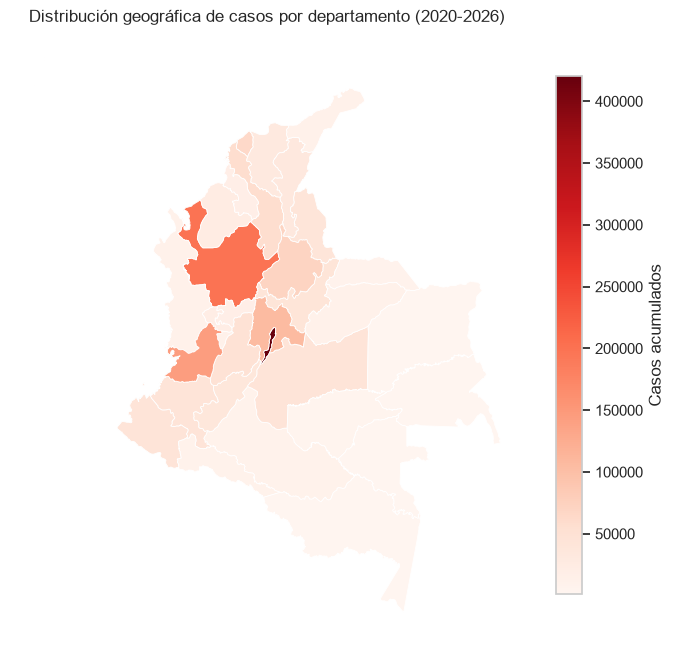

In [9]:
import json

from matplotlib.patches import Polygon as PoligonoMpl
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize

TABLA_TILDES_MAPA = str.maketrans("áéíóúüÁÉÍÓÚÜ", "aeiouuAEIOUU")


def _normalizar_nombre(texto):
    return str(texto).translate(TABLA_TILDES_MAPA).strip().upper()


# El geojson público usa nombres ligeramente distintos para 3 departamentos.
ALIAS_GEOJSON = {
    "BOGOTA": "SANTAFE DE BOGOTA D.C",
    "GUAJIRA": "LA GUAJIRA",
    "SAN ANDRES": "ARCHIPIELAGO DE SAN ANDRES PROVIDENCIA Y SANTA CATALINA",
}

ruta_geojson = RAIZ_PROYECTO / "data" / "geo" / "colombia_departamentos.geojson"
with open(ruta_geojson, encoding="utf-8") as archivo:
    geo_departamentos = json.load(archivo)

casos_departamento = df.groupby("DEPARTAMENTO")["CANTIDAD"].sum()
valor_por_nombre_geo = {
    _normalizar_nombre(ALIAS_GEOJSON.get(depto, depto)): valor
    for depto, valor in casos_departamento.items()
}

fig, ax = plt.subplots(figsize=(7, 9))
cmap = plt.colormaps["Reds"]
norm = Normalize(vmin=casos_departamento.min(), vmax=casos_departamento.max())

parches, colores = [], []
for feature in geo_departamentos["features"]:
    nombre_geo = _normalizar_nombre(feature["properties"]["NOMBRE_DPT"])
    valor = valor_por_nombre_geo.get(nombre_geo, 0)
    geometria = feature["geometry"]
    poligonos = geometria["coordinates"] if geometria["type"] == "MultiPolygon" else [geometria["coordinates"]]
    for poligono in poligonos:
        parches.append(PoligonoMpl(poligono[0]))
        colores.append(valor)

coleccion = PatchCollection(parches, array=np.array(colores), cmap=cmap, norm=norm, edgecolor="white", linewidth=0.6)
ax.add_collection(coleccion)
ax.autoscale_view()
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Distribución geográfica de casos por departamento (2020-2026)")
fig.colorbar(coleccion, ax=ax, orientation="vertical", label="Casos acumulados", shrink=0.6)
plt.tight_layout()
plt.show()

**Hallazgo:** los casos se concentran fuertemente en el centro y suroccidente del país — Bogotá, Antioquia y Valle del Cauca dominan visualmente el mapa — mientras que los departamentos de la Amazonía y la Orinoquía (Vaupés, Guainía, Amazonas, Vichada) casi no se distinguen del color más claro.

**Evidencia:** Bogotá concentra sola el 26% del total nacional (420.531 de 1.605.036 casos), y junto con Antioquia y Valle del Cauca suman cerca del 48% del total; en el otro extremo, Vaupés, Guainía y Amazonas no superan los 1.300 casos cada uno en siete años.

**Precaución** No se evidencia el contraste de cantidad de delitos cometidos por departamento versus la población que lo habita.


## Pregunta 3 (Dispersión): ¿existe relación entre el número de casos de un departamento en 2020 y en 2025?

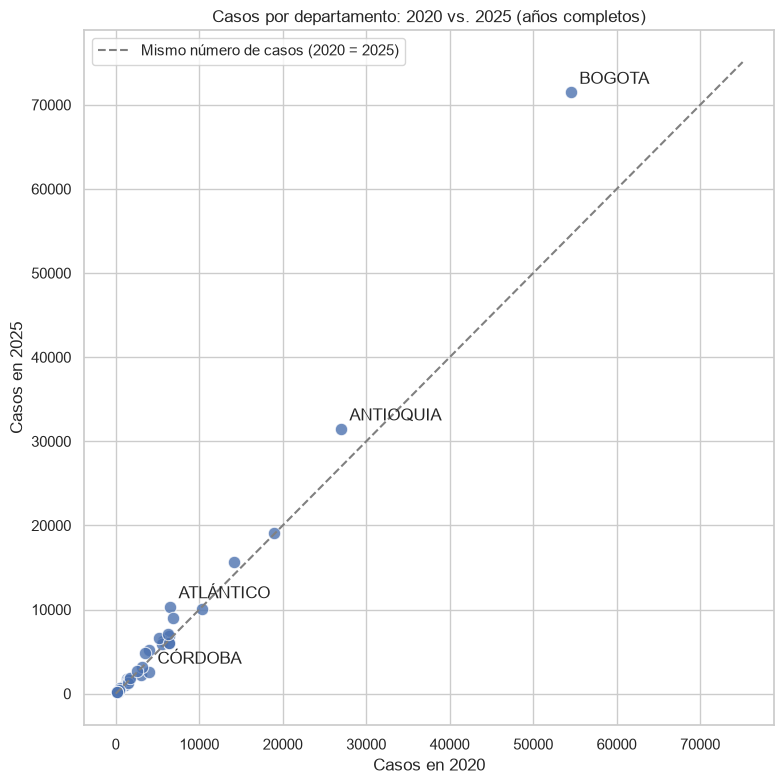

In [10]:
por_anio = df.groupby(["DEPARTAMENTO", "AÑO"])["CANTIDAD"].sum().unstack(fill_value=0)
por_anio.columns = [str(c) for c in por_anio.columns]
por_anio = por_anio.reset_index()

plt.figure(figsize=(8, 8))
sns.scatterplot(data=por_anio, x="2020", y="2025", s=80, alpha=0.8)

limite = max(por_anio["2020"].max(), por_anio["2025"].max()) * 1.05
plt.plot([0, limite], [0, limite], linestyle="--", color="gray", label="Mismo número de casos (2020 = 2025)")

destacados = por_anio[por_anio["DEPARTAMENTO"].isin(["BOGOTA", "ANTIOQUIA", "CÓRDOBA", "ATLÁNTICO"])]
for _, fila in destacados.iterrows():
    plt.annotate(fila["DEPARTAMENTO"], (fila["2020"], fila["2025"]), textcoords="offset points", xytext=(6, 6))

plt.title("Casos por departamento: 2020 vs. 2025 (años completos)")
plt.xlabel("Casos en 2020")
plt.ylabel("Casos en 2025")
plt.legend()
plt.tight_layout()
plt.show()

**Hallazgo:** existe una relación muy fuerte y positiva (haciendo referncia a un valor creciente, debidoa que el caso expone preocupación en el aumento de los delitos) entre el número de casos de un departamento en 2020 y en 2025: el tamaño relativo de cada departamento se mantiene bastante estable en cinco años, aunque no es idéntico.

**Evidencia:** casi todos los puntos se ubican muy cerca de la línea de igualdad (2020 = 2025), y Bogotá y Antioquia se separan claramente del resto por su volumen. Algunos departamentos sí se apartan de esa línea en ambas direcciones: Atlántico queda por encima (aumentó cerca de 59% entre 2020 y 2025), mientras que Córdoba y Caldas quedan por debajo (cayeron cerca de 36% y 28%, respectivamente).

**Precaución:** No se puede medir la magnitud del cambio de forma gradual en cada departamento afectado.